In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline


In [3]:
df=pd.read_csv("homeprices_banglore.csv")
df.sample(5)

,area,bedrooms,price
18,2770,3,102.0
12,1000,2,38.0
10,1800,3,82.0
5,1170,2,38.0
7,3300,4,155.0


In [4]:
from sklearn import preprocessing
sx=preprocessing.MinMaxScaler()
sy=preprocessing.MinMaxScaler()
scaled_x=sx.fit_transform(df.drop('price',axis='columns'))
scaled_x

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [5]:
scaled_y=sy.fit_transform(df['price'].values.reshape(df.shape[0],1))
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [6]:
w=np.ones(shape=(2))

In [7]:
np.dot(w,scaled_x.T)

array([0.33827586, 1.37068966, 0.72068966, 0.74862069, 0.38793103,
       0.37758621, 1.4162069 , 1.61206897, 0.67586207, 2.        ,
       0.84482759, 1.43448276, 0.31896552, 0.35344828, 1.        ,
       0.37931034, 0.63103448, 0.75517241, 1.17931034, 0.        ])

In [8]:
a=np.array([1,2,3])
b=np.array([10,5,7])
a-b

array([-9, -3, -4])

In [9]:
import numpy as np

def batch_gradient_descent(x, y_true, epochs, learning_rate=0.01): 
    number_of_features = x.shape[1]
    w = np.ones(shape=(number_of_features))
    b = 0
    total_samples = x.shape[0]
    cost_list = []
    epoch_list = []
    
    for i in range(epochs):
        y_predicted = np.dot(x, w) + b 
        
        w_grad = (2 / total_samples) * (x.T.dot(y_predicted - y_true))
        b_grad = (2 / total_samples) * np.sum(y_predicted - y_true)
        
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        
        cost = np.mean(np.square(y_true - y_predicted))
        
        if i % 10 == 0:
            cost_list.append(cost)
            epoch_list.append(i) 
            
    return w, b, cost, cost_list, epoch_list

w, b, cost, cost_list, epoch_list = batch_gradient_descent(
    scaled_x, 
    scaled_y.reshape(scaled_y.shape[0],), 
    500
)

print(f"Weights: {w}")
print(f"Bias: {b}")
print(f"Final Cost: {cost}")

Weights: [0.70712464 0.67456527]
Bias: -0.23034857438407427
Final Cost: 0.0068641890429808105


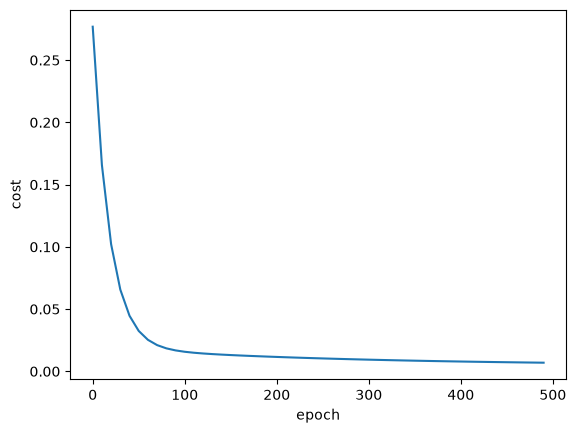

In [10]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

In [14]:
def predict(area, bedroom, w, b):
    scaled_x = sx.transform([[area, bedroom]])[0]
    
    scaled_price = np.dot(w, scaled_x) + b
    
    predicted_price = sy.inverse_transform([[scaled_price]])[0][0]
    
    return predicted_price

predict(2600, 4, w, b)

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(128.45484403267596)

In [15]:
predict(1000,2,w,b)

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(30.253094462442355)

In [27]:
import random
import numpy as np

def stochastic_gradient_descent(x, y_true, epochs, learning_rate=0.01): 
    number_of_features = x.shape[1]
    w = np.ones(shape=(number_of_features))
    b = 0
    total_samples = x.shape[0]
    cost_list = []
    epoch_list = []
    
    for i in range(epochs):
        random_index = random.randint(0, total_samples - 1)
        sample_x = x[random_index]
        sample_y = y_true[random_index]
        
        y_predicted = np.dot(w, sample_x) + b

        w_grad = 2 * (y_predicted - sample_y) * sample_x
        b_grad = 2 * (y_predicted - sample_y)
        
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        
        cost = np.square(sample_y - y_predicted)
        
        if i % 100 == 0:
            cost_list.append(cost) 
            epoch_list.append(i)
            
    return w, b, cost, cost_list, epoch_list

w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(
    scaled_x,
    scaled_y.reshape(scaled_y.shape[0]),
    10000
)

print(f"Weights (SGD): {w_sgd}")
print(f"Bias (SGD): {b_sgd}")
print(f"Final Single-Sample Cost: {cost_sgd}")

Weights (SGD): [0.8293069  0.30665838]
Bias (SGD): -0.08856202804483845
Final Single-Sample Cost: 0.0004075562567528893


In [28]:
w,b,cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

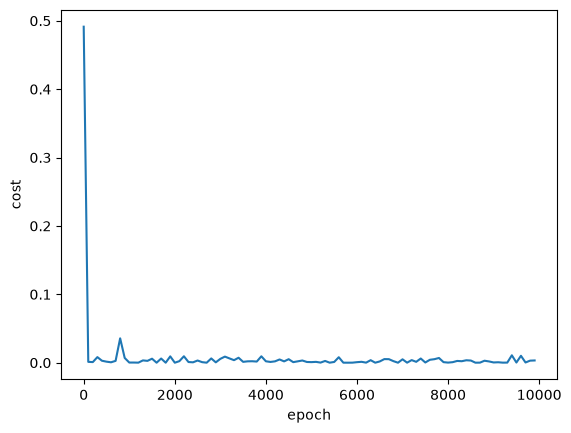

In [29]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_sgd,cost_list_sgd)